<a href="https://colab.research.google.com/github/springboardmentor1234r/B13-AirFly-Insights-Internship/blob/Devika_S_Nair/milestone_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AirFly Insights: Data Visualization and Analysis of Airline Operations**

***MILESTONE 3***

Route, Cancellation, and Seasonal Insights

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_parquet("/content/drive/MyDrive/airline_cleaned.parquet")

WEEK 5
Route and Airport-Level Analysis

Top 10 Origin–Destination Pairs

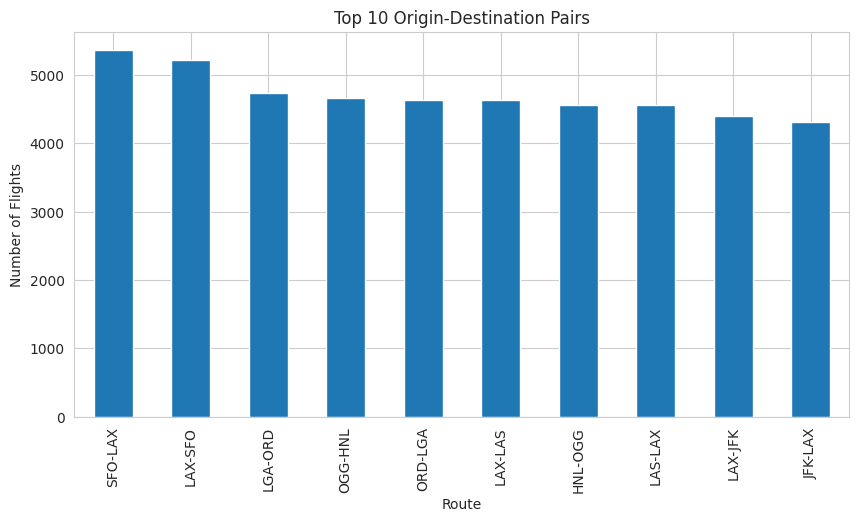

In [4]:
top_routes = df['ROUTE'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_routes.plot(kind='bar')

plt.title("Top 10 Origin-Destination Pairs")
plt.xlabel("Route")
plt.ylabel("Number of Flights")

plt.show()

Delay Heatmap by Airport

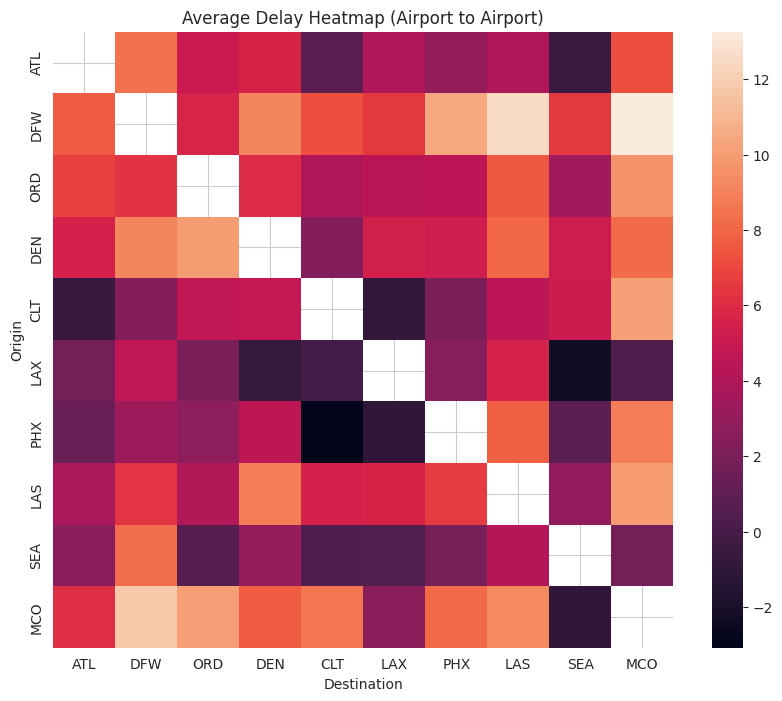

In [5]:
pivot_airport = df.pivot_table(
    values='ARR_DELAY',
    index='ORIGIN',
    columns='DEST',
    aggfunc='mean'
)

# Reduce size (top airports only)
top_airports = df['ORIGIN'].value_counts().head(10).index
pivot_airport = pivot_airport.loc[top_airports, top_airports]

plt.figure(figsize=(10,8))
sns.heatmap(pivot_airport, annot=False)

plt.title("Average Delay Heatmap (Airport to Airport)")
plt.xlabel("Destination")
plt.ylabel("Origin")

plt.show()

Route-Level Delay Heatmap (Top Routes)


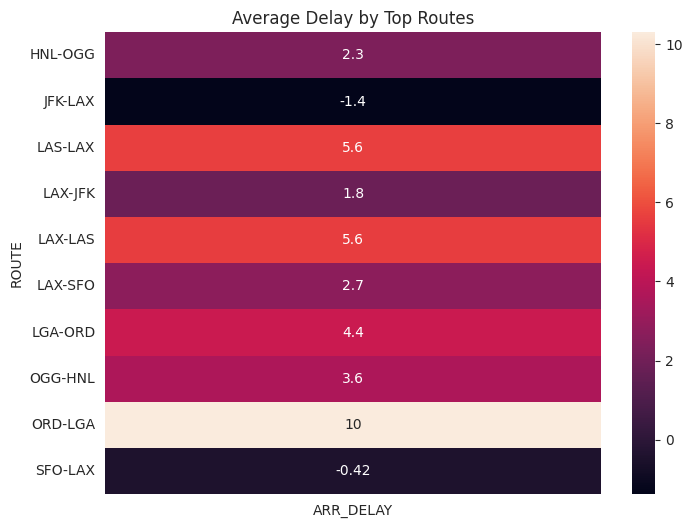

In [6]:
top_routes_list = df['ROUTE'].value_counts().head(10).index

route_data = df[df['ROUTE'].isin(top_routes_list)]

pivot_route = route_data.pivot_table(
    values='ARR_DELAY',
    index='ROUTE',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_route, annot=True)

plt.title("Average Delay by Top Routes")

plt.show()

Busiest Airports

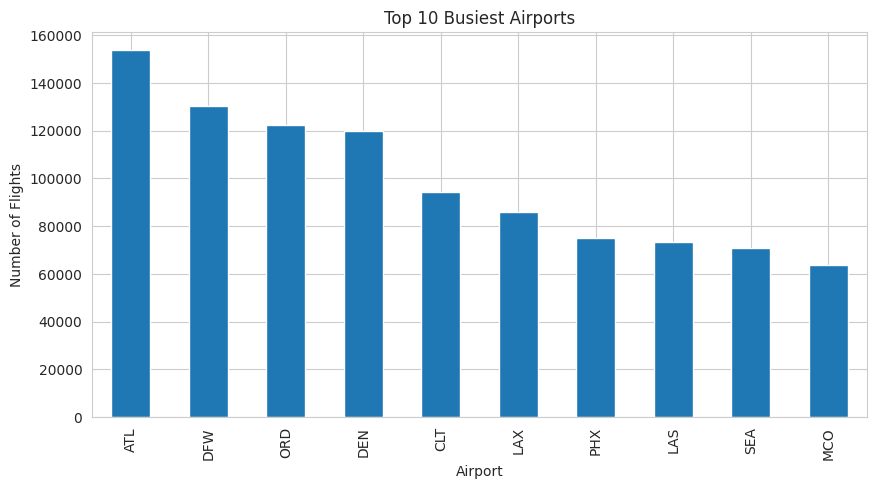

In [7]:
top_airports = df['ORIGIN'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_airports.plot(kind='bar')

plt.title("Top 10 Busiest Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")

plt.show()

Average Delay by Airport

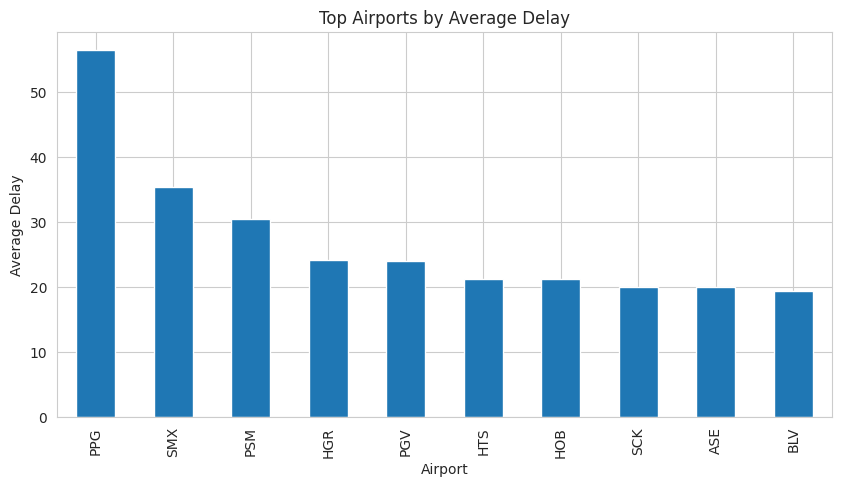

In [8]:
airport_delay = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
airport_delay.plot(kind='bar')

plt.title("Top Airports by Average Delay")
plt.xlabel("Airport")
plt.ylabel("Average Delay")

plt.show()

WEEK 6

Monthly Cancellation Trends

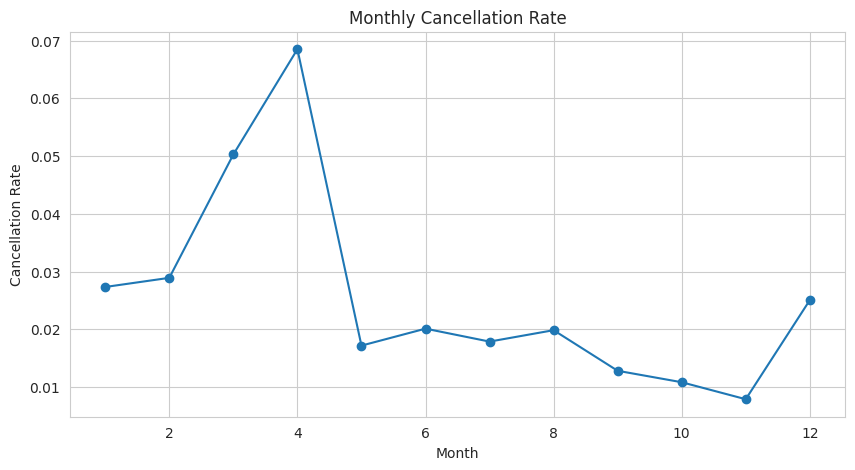

In [9]:
monthly_cancel = df.groupby('MONTH')['CANCELLED'].mean()

plt.figure(figsize=(10,5))
monthly_cancel.plot(marker='o')

plt.title("Monthly Cancellation Rate")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate")

plt.show()

Cancellation Types Analysis

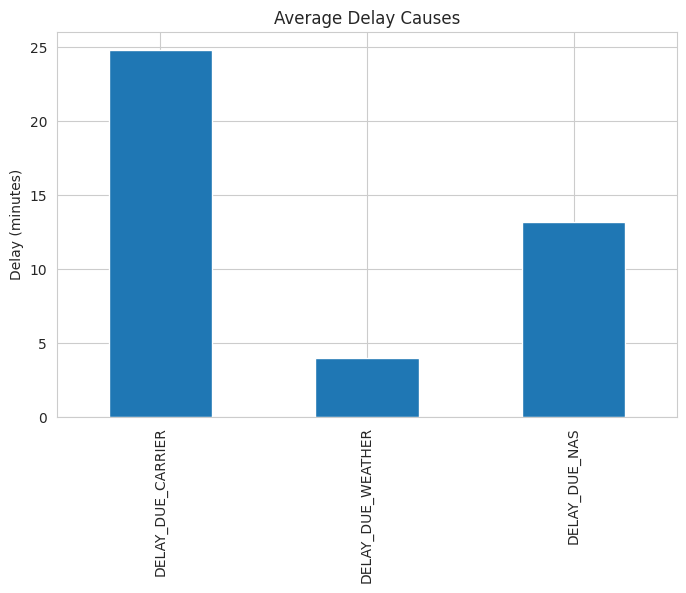

In [10]:
cancel_cols = ['DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS']

cancel_data = df[cancel_cols].mean()

plt.figure(figsize=(8,5))
cancel_data.plot(kind='bar')

plt.title("Average Delay Causes")
plt.ylabel("Delay (minutes)")

plt.show()

Cancellation Distribution (Cancelled vs Not)

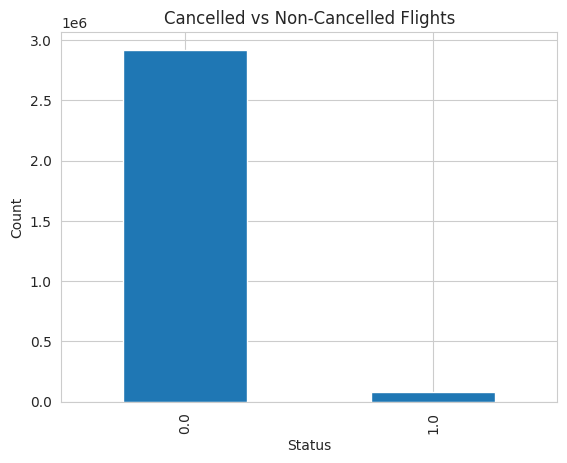

In [11]:
df['CANCELLED'].value_counts().plot(kind='bar')

plt.title("Cancelled vs Non-Cancelled Flights")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

Seasonal Delay Analysis (Winter Effect)

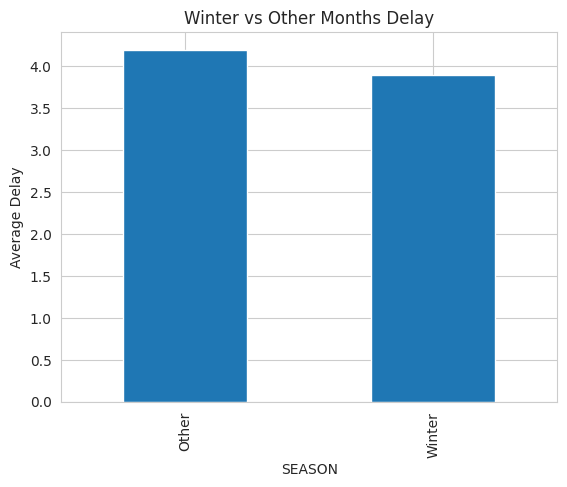

In [12]:
winter_months = [12, 1, 2]

df['SEASON'] = df['MONTH'].apply(lambda x: 'Winter' if x in winter_months else 'Other')

season_delay = df.groupby('SEASON')['ARR_DELAY'].mean()

season_delay.plot(kind='bar')

plt.title("Winter vs Other Months Delay")
plt.ylabel("Average Delay")

plt.show()

Monthly Delay Trend

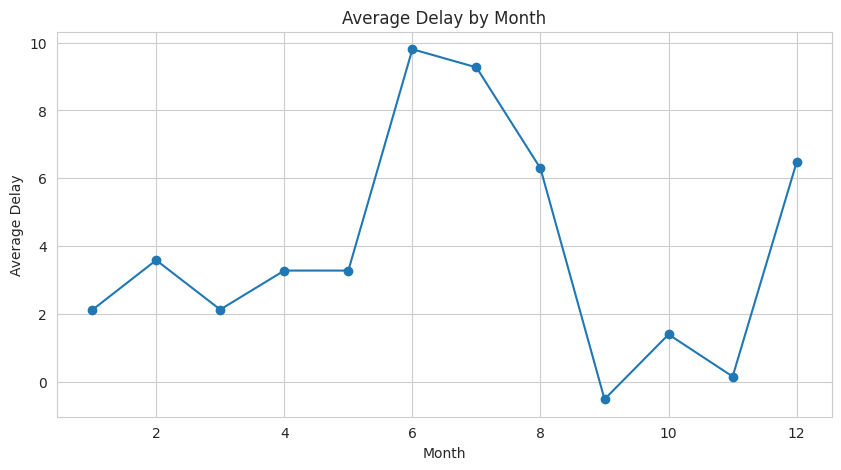

In [13]:
monthly_delay = df.groupby('MONTH')['ARR_DELAY'].mean()

plt.figure(figsize=(10,5))
monthly_delay.plot(marker='o')

plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay")

plt.show()

# -------------------- Insights from Analysis --------------------

# 1. Certain routes show consistently high traffic and also experience higher delays,
#    indicating possible congestion on popular routes.

# 2. Some airports have higher average delays compared to others,
#    which may be due to heavy traffic, operational inefficiencies, or weather conditions.

# 3. Cancellation rates are not uniform and vary across different months,
#    suggesting seasonal or operational influences.

# 4. Winter months (December, January, February) tend to have higher delays,
#    likely due to weather-related disruptions.

# 5. Different delay causes contribute differently:
#    - Carrier delays are more frequent and airline-dependent
#    - Weather delays are less frequent but can be severe
#    - NAS delays occur due to air traffic congestion

# ---------------------------------------------------------------